
# Limpieza y Preparación del Dataset - Proyecto FraudIQ

## Introducción

El presente notebook corresponde a la primera etapa del proyecto final de la asignatura de Aprendizaje Automático, titulado **FraudIQ**. En este proyecto nos proponemos desarrollar un sistema inteligente de detección de fraude financiero a partir de un conjunto de datos reales o sintéticos de transacciones bancarias. Esta fase inicial se enfoca en la **recolección, inspección, limpieza y transformación del dataset**, con el fin de garantizar la calidad y coherencia de los datos que serán utilizados para el entrenamiento de modelos de clasificación supervisada.

Entre las tareas contempladas se incluyen: manejo de valores faltantes, tratamiento de variables categóricas, verificación de tipos de datos, detección de outliers y normalización de características numéricas. Todo este proceso se realiza para asegurar que los algoritmos de aprendizaje automático puedan operar de manera eficiente y obtener resultados confiables.

## Fuente del Dataset

El conjunto de datos utilizado en este proyecto fue obtenido de Kaggle, específicamente del siguiente enlace:

[Fraud Detection Dataset - Kaggle](https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset)

Este dataset contiene múltiples atributos relacionados con transacciones financieras, que serán explorados y preparados en las siguientes celdas.

## Autores del proyecto

> REALIZADO POR DEYBBY ROSARIO 2024-0504 Y SARAH PEÑA 2024-0506

## Paso 1: Importación de Librerías

Como primer paso en el desarrollo de este proyecto, importamos las principales librerías necesarias para el análisis de datos, limpieza, visualización y preparación de información para su posterior uso en modelos de clasificación.

In [1]:
# Importación de librerías fundamentales para análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Paso 1.1 Configuración de la Paleta de Colores

Con el objetivo de mantener una identidad visual coherente a lo largo del proyecto, se define en esta etapa la **paleta de colores oficial del producto FraudIQ**. Esta configuración será utilizada durante todo el proceso de análisis exploratorio de datos (EDA) y generación de visualizaciones.

La paleta incluye colores distintivos que representan la imagen visual del sistema, y será aplicada mediante la librería `seaborn` para asegurar consistencia en todas las gráficas del proyecto.

In [2]:
# Configuración de estilo de gráficos
plt.style.use('ggplot')

# Paleta de colores oficial del proyecto FraudIQ
fraudiq_palette = ["#4DB6AC", "#29B6F6", "#B0BEC5", "#FAFAFA", "#263238", "#FDDD0D"]
sns.set_palette(fraudiq_palette)

## Paso 2: Carga del Dataset

Para trabajar con el conjunto de datos de detección de fraude financiero, ofrecemos dos opciones de carga:

1. **Carga automática desde Kaggle**  

2. **Carga manual desde archivo local**  

In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("amanalisiddiqui/fraud-detection-dataset")

# Cargar el archivo CSV en un DataFrame
try:
    file_path = os.path.join(path, "AIML Dataset.csv")
    df = pd.read_csv(file_path)
    print("Dataset cargado correctamente desde KaggleHub.")
except Exception as e:
    print("No se encontró el archivo en la ruta de Kaggle. Intentando cargar desde archivo local...")
    try:
        df = pd.read_csv("AIML Dataset.csv")
        print("Dataset cargado correctamente desde archivo local.")
    except Exception as e2:
        print("Error: No se pudo cargar el dataset desde ninguna fuente.")
        print("Detalle del error:", e2)

100%|██████████| 178M/178M [00:02<00:00, 66.2MB/s]

Extracting files...


Dataset cargado correctamente desde KaggleHub.


In [4]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


## Paso 3: Inspección Inicial del Dataset

Una vez cargado el dataset, se procede a realizar una verificación estructural básica que nos permita conocer las dimensiones del conjunto de datos, los nombres de las columnas y el tipo de datos contenido en cada una de ellas. Esta inspección es fundamental para planificar adecuadamente las tareas de limpieza, codificación y análisis exploratorio posteriores.


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
# Verificar dimensiones del dataset
print("Número de filas y columnas del dataset:", df.shape)

# Listar los nombres de las columnas
print("\nColumnas del dataset:")
print(df.columns.tolist())

# Verificar tipos de datos y valores nulos
print("\nInformación general del dataset:")
df.info()

Número de filas y columnas del dataset: (6362620, 11)

Columnas del dataset:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


#### Significado de los campos (columnas):

* `step` - Representa una unidad de tiempo en el mundo real. En este caso, 1 paso equivale a 1 hora de tiempo. Total de pasos: 744 (simulación de 30 días).

* `type` - Tipo de transacción: CASH-IN (depósito), CASH-OUT (retiro), DEBIT (débito), PAYMENT (pago) y TRANSFER (transferencia).

* `amount` - Monto de la transacción en la moneda local.

* `nameOrig` - Cliente que inició la transacción.

* `oldbalanceOrg` - Saldo inicial antes de la transacción.

* `newbalanceOrig` - Nuevo saldo después de la transacción.

* `nameDest` - Cliente que recibe la transacción.

* `oldbalanceDest` - Saldo inicial del destinatario antes de la transacción.
  - *Nota:* No hay información para clientes cuyo nombre comienza con "M" (Comerciantes).

* `newbalanceDest` - Nuevo saldo del destinatario después de la transacción.
  - *Nota:* No hay información para clientes cuyo nombre comienza con "M" (Comerciantes).

* `isFraud` - Indica si la transacción fue realizada por agentes fraudulentos dentro de la simulación. En este conjunto de datos, el comportamiento fraudulento de los agentes busca obtener beneficios tomando el control de cuentas de clientes y tratando de vaciar los fondos mediante transferencias a otra cuenta y posterior retiro del sistema.

* `isFlaggedFraud`: Indica si el sistema levantó una alerta de posible fraude en una transacción determinada. Esta columna no determina si la transacción fue efectivamente fraudulenta, sino si fue identificada como tal por el sistema en base a reglas internas.

## Paso 4: Análisis Estadístico Preliminar

Antes de iniciar el proceso de limpieza, se realiza una revisión general de las variables numéricas del dataset. Esto incluye estadísticas descriptivas como media, mediana, mínimo, máximo y desviación estándar. Además, se verifica la existencia de valores nulos y registros duplicados que pudieran afectar el análisis o el entrenamiento de los modelos.

In [7]:
# Ajustar el formato de salida de pandas para evitar notación científica
pd.set_option('display.float_format', '{:.2f}'.format)

print("Estadísticas generales del dataset:")
display(df.describe())

# Verificar la cantidad de valores nulos por columna
print("\nConteo de valores nulos por columna:")
print(df.isnull().sum())

# Verificar la cantidad de registros duplicados
duplicados = df.duplicated().sum()
print(f"\nCantidad de registros duplicados en el dataset: {duplicados}")

Estadísticas generales del dataset:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00
mean,243.40,179861.90,833883.10,855113.67,1100701.67,1224996.40,0.00,0.00
std,142.33,603858.23,2888242.67,2924048.50,3399180.11,3674128.94,0.04,0.00
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,156.00,13389.57,0.00,0.00,0.00,0.00,0.00,0.00
50%,239.00,74871.94,14208.00,0.00,132705.66,214661.44,0.00,0.00
75%,335.00,208721.48,107315.18,144258.41,943036.71,1111909.25,0.00,0.00
max,743.00,92445516.64,59585040.37,49585040.37,356015889.35,356179278.92,1.00,1.00



Conteo de valores nulos por columna:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Cantidad de registros duplicados en el dataset: 0


## Paso 5: Visualización de la Distribución de Datos

Después de confirmar que el dataset está completo (sin valores nulos) y no contiene filas duplicadas, el siguiente paso es visualizar la distribución de las variables numéricas.

Generaremos:

- Histogramas: Para observar la forma de la distribución de cada variable numérica.

- Boxplots (Diagramas de Caja): Para identificar la mediana, los cuartiles y, de manera crucial, la presencia de valores atípicos (outliers).

Esto nos permite obtener una comprensión más intuitiva de los datos que no es aparente solo con las estadísticas descriptivas.

Generando histogramas para las variables numéricas...


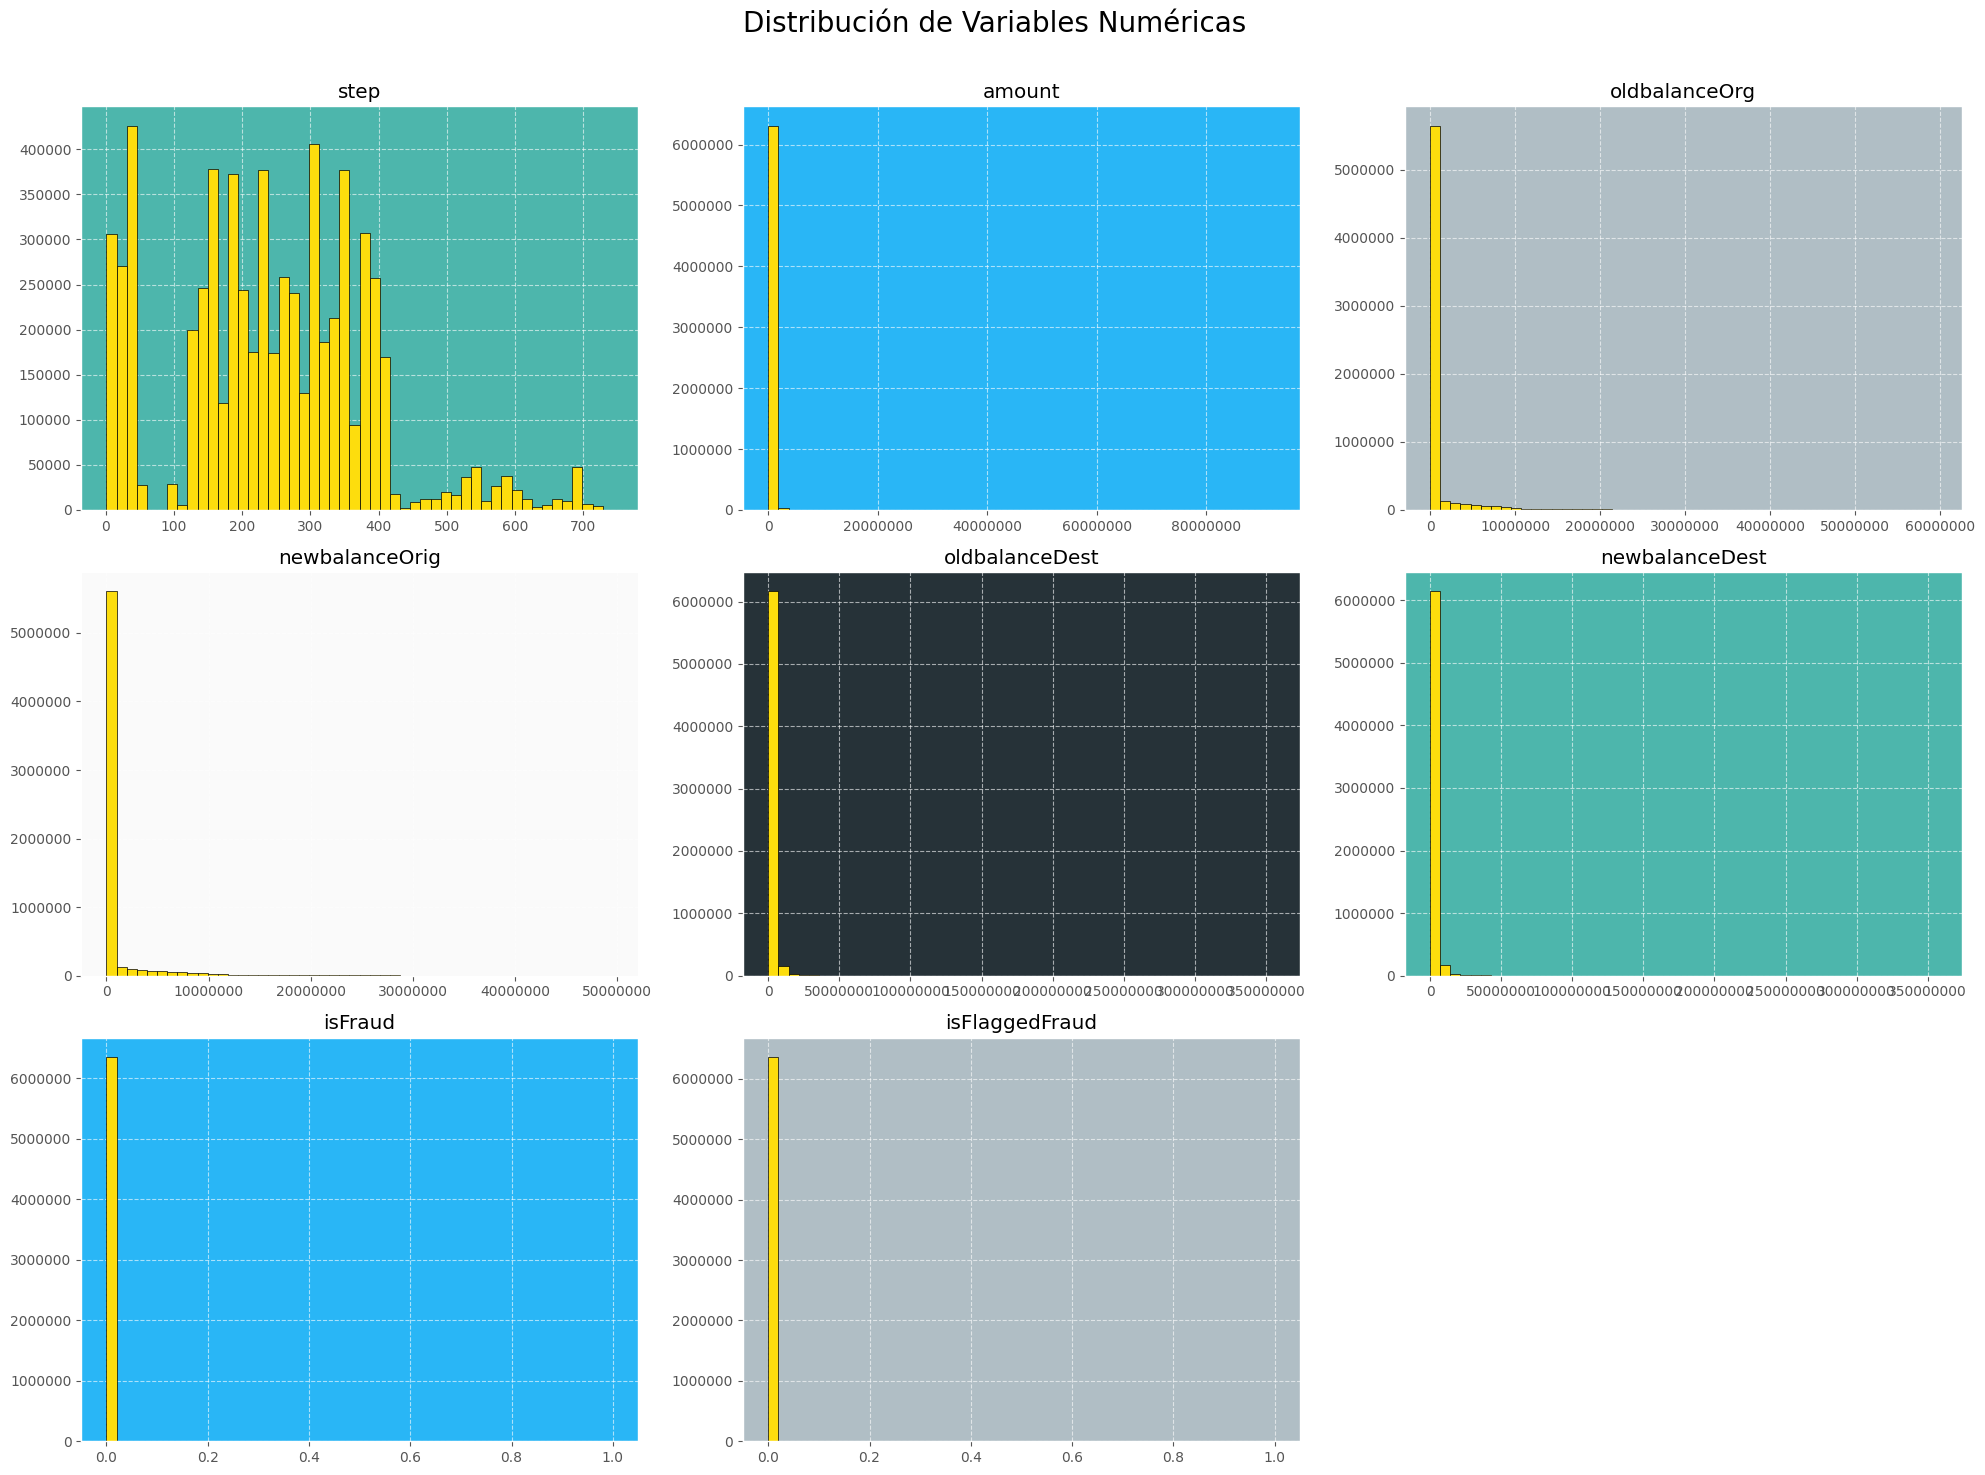

In [8]:
# 1. Histogramas para todas las variables numéricas
print("Generando histogramas para las variables numéricas...")

# Color específico para los bins del histograma
bin_color = "#FDDD0D"

# Extraer solo las columnas numéricas
df_numeric = df.select_dtypes(include=np.number)

# Generar los histogramas y guardar los ejes
axes = df_numeric.hist(bins=50, figsize=(20, 15), color=bin_color, edgecolor="black", grid=False)

# Aplanar la matriz de ejes
axes_flat = axes.flatten()

# Iterar sobre cada eje para aplicar formato y color de fondo
background_palette = fraudiq_palette[:-1] # Excluimos el amarillo que ya usamos para los bins
for i, ax in enumerate(axes_flat):
    # Asignar un color de fondo de la paleta de forma cíclica
    ax.set_facecolor(background_palette[(i) % len(background_palette)])

    # Desactivar la notación científica
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')

    # Reactivar el grid con estilo sutil
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Distribución de Variables Numéricas", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Generando boxplots para detectar outliers en variables financieras...


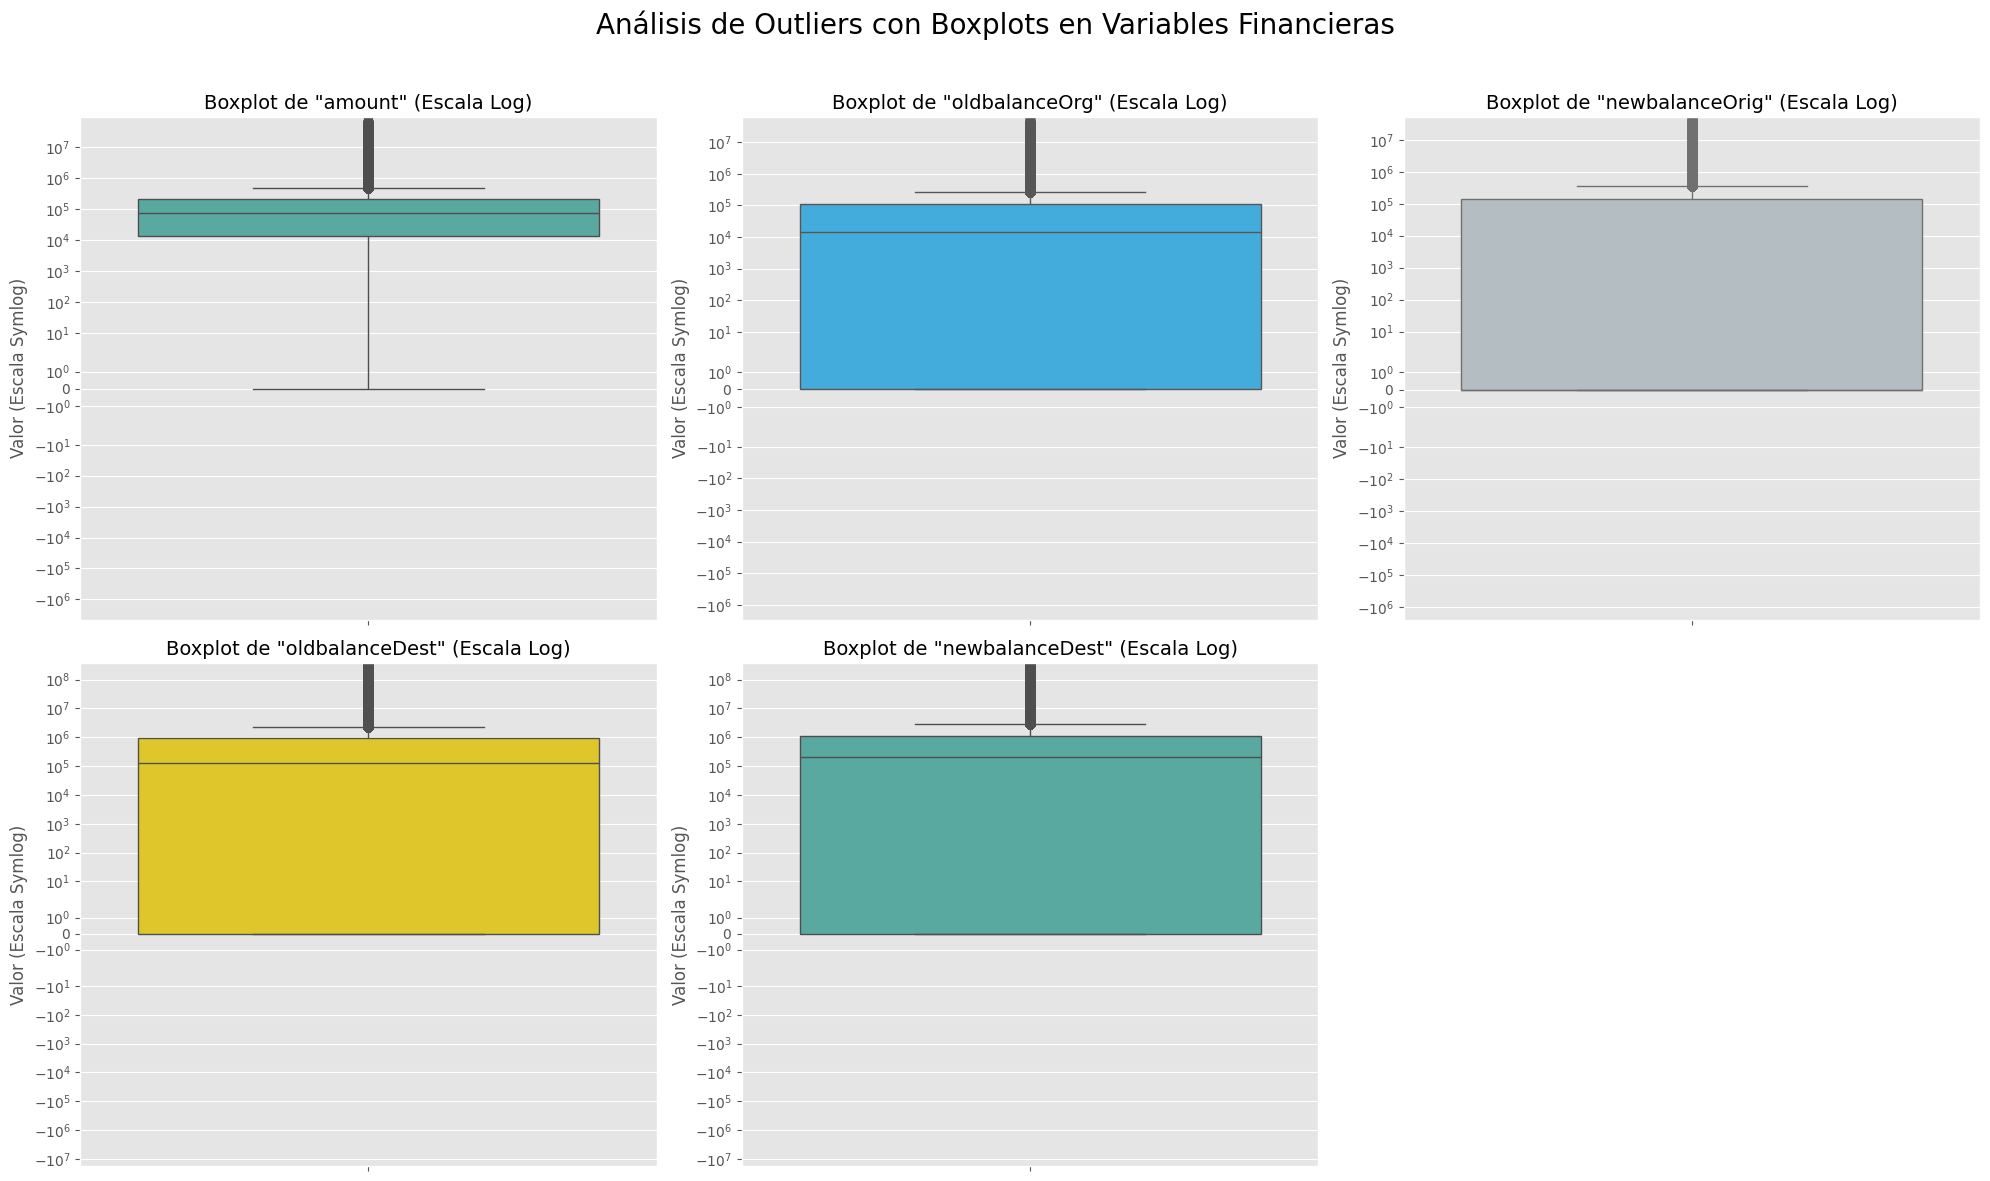

In [9]:
# 2. Boxplots para las variables financieras clave
print("Generando boxplots para detectar outliers en variables financieras...")
plt.figure(figsize=(20, 12))

# Paleta de colores oficial del proyecto FraudIQ
fraudiq_palette_2 = ["#4DB6AC", "#29B6F6", "#B0BEC5", "#FDDD0D"]

# Variables financieras a graficar
variables_financieras = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

# Iterar para crear cada boxplot en un subplot
for i, col in enumerate(variables_financieras):
    ax = plt.subplot(2, 3, i + 1)

    # Crear el boxplot asignando un color de la paleta de forma cíclica
    sns.boxplot(y=df[col], color=fraudiq_palette_2[i % len(fraudiq_palette_2)], ax=ax)

    # Cambiar la escala del eje Y a logarítmica simétrica
    # 'symlog' permite visualizar rangos amplios y maneja correctamente el valor 0
    ax.set_yscale('symlog')

    ax.set_title(f'Boxplot de "{col}" (Escala Log)', fontsize=14)
    ax.set_ylabel("Valor (Escala Symlog)")
    ax.set_xlabel("")

plt.suptitle("Análisis de Outliers con Boxplots en Variables Financieras", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Interpretación de las Visualizaciones

- Conclusiones de los Histogramas

Los histogramas de las variables numéricas, especialmente de amount y las columnas de balance, revelan que la distribución de los datos no es normal ni óptima para muchos algoritmos de machine learning.

Se observa un fuerte sesgo positivo (o sesgo a la derecha). Esto se manifiesta en que la gran mayoría de las transacciones se concentran en un único bin de bajo valor (con una frecuencia que supera los 6 millones de registros), mientras que una larga cola de valores mucho más altos se extiende hacia la derecha. Esta asimetría indica que la mayoría de las transacciones son de montos pequeños, con unas pocas transacciones de montos excepcionalmente altos.

- Conclusiones de los Boxplots

Para poder analizar la estructura de los datos, fue indispensable utilizar una escala logarítmica simétrica (symlog) en los diagramas de caja. Sin esta transformación, la visualización era inviable, ya que la caja (que representa el 50% central de los datos) quedaba completamente comprimida e invisible debido a la magnitud de los valores atípicos (outliers).

La visualización en escala logarítmica confirma la presencia de una cantidad masiva de outliers. Estos puntos, que se sitúan muy por encima de los bigotes del diagrama, corresponden a las transacciones de alto valor que generan el sesgo observado en los histogramas. Este hallazgo confirma la necesidad de definir e implementar una estrategia formal para el tratamiento de outliers antes de proceder con el entrenamiento de los modelos.

Dicho esto, el proceso de limpieza y preprocesamiento debe ser reenfocado, en el sentido de que no será óptimo para el modelo a crear con el rango completo de las transacciones, por lo cual hay que definir si nos basamos en el grueso de las transacciones de bajo valor incluidos en la escala intercuartil o si nos enfocamos en transacciones de alto valor, ahora mismo tratadas como outliers.

## Paso 6: Cuantificación de Outliers vs. Datos Intercuartiles

Para decidir la estrategia de limpieza, primero analizaremos cuantitativamente los dos principales segmentos de datos en la variable amount:

1. Datos Intercuartiles: Transacciones consideradas "normales" según el método del Rango Intercuartílico (IQR).

2. Datos Atípicos (Outliers): Transacciones que exceden los límites definidos por el método IQR.

Calcularemos cuántas transacciones, qué porcentaje del total y, lo más importante, cuántos casos de fraude existen en cada uno de estos universos.

In [10]:
# 1. Calcular el Rango Intercuartílico (IQR) para la columna 'amount'
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

# 2. Definir los límites para detectar outliers
# Un factor común es 1.5, pero podemos ajustarlo si es necesario.
factor = 1.5
limite_superior = Q3 + (IQR * factor)
limite_inferior = Q1 - (IQR * factor)

print(f"Límite inferior para outliers: {limite_inferior:.2f}")
print(f"Límite superior para outliers: {limite_superior:.2f}\n")


# 3. Separar el dataset en outliers y datos intercuartiles
df_outliers = df[(df['amount'] < limite_inferior) | (df['amount'] > limite_superior)]
df_inliers = df[(df['amount'] >= limite_inferior) & (df['amount'] <= limite_superior)]

Límite inferior para outliers: -279608.29
Límite superior para outliers: 501719.34



In [11]:
# 4. Analizar el universo de OUTLIERS
print("--- Análisis del Universo de Outliers ---")
num_outliers = len(df_outliers)
porcentaje_outliers = (num_outliers / len(df)) * 100
fraude_en_outliers = df_outliers['isFraud'].sum()
porcentaje_fraude_outliers = (fraude_en_outliers / df['isFraud'].sum()) * 100 if df['isFraud'].sum() > 0 else 0

print(f"Número de transacciones: {num_outliers}")
print(f"Porcentaje del total de transacciones: {porcentaje_outliers:.2f}%")
print(f"Número de transacciones fraudulentas: {fraude_en_outliers}")
print(f"Esto representa el {porcentaje_fraude_outliers:.2f}% de TODO el fraude.\n")

--- Análisis del Universo de Outliers ---
Número de transacciones: 338078
Porcentaje del total de transacciones: 5.31%
Número de transacciones fraudulentas: 3854
Esto representa el 46.93% de TODO el fraude.



In [12]:
# 5. Analizar el universo de INLIERS (datos "normales")
print("--- Análisis del Universo de Datos Intercuartiles (Inliers) ---")
num_inliers = len(df_inliers)
porcentaje_inliers = (num_inliers / len(df)) * 100
fraude_en_inliers = df_inliers['isFraud'].sum()
porcentaje_fraude_inliers = (fraude_en_inliers / df['isFraud'].sum()) * 100 if df['isFraud'].sum() > 0 else 0

print(f"Número de transacciones: {num_inliers}")
print(f"Porcentaje del total de transacciones: {porcentaje_inliers:.2f}%")
print(f"Número de transacciones fraudulentas: {fraude_en_inliers}")
print(f"Esto representa el {porcentaje_fraude_inliers:.2f}% de TODO el fraude.")

--- Análisis del Universo de Datos Intercuartiles (Inliers) ---
Número de transacciones: 6024542
Porcentaje del total de transacciones: 94.69%
Número de transacciones fraudulentas: 4359
Esto representa el 53.07% de TODO el fraude.


El análisis cuantitativo revela una dualidad crítica en el comportamiento del fraude. Por un lado, las transacciones de alto valor, que representan apenas un 5.31% del total de los datos (los "outliers"), concentran un alarmante 46.93% de todos los casos de fraude. Esto confirma que las transacciones atípicas son un indicador de alto riesgo que no puede ser ignorado o eliminado.

Por otro lado, la mayoría de los incidentes fraudulentos (53.07%) se encuentran dispersos entre más de 6 millones de transacciones consideradas "normales" (los "inliers"). Entrenar un modelo únicamente con los fraudes de alto valor lo dejaría ciego ante el tipo de fraude más común, aunque de menor monto. Por lo tanto, el desafío es encontrar un punto medio: un enfoque de limpieza y muestreo que conserve la representatividad de ambos escenarios para construir un modelo robusto y sin sesgos.

## Paso 7: Análisis del Rango de Montos en Transacciones Fraudulentas

Para definir ese "punto medio", el siguiente paso es entender las características específicas de los montos en las transacciones fraudulentas de cada universo. Calcularemos las estadísticas descriptivas (como el promedio, mínimo, máximo y la mediana) del amount para los fraudes dentro del grupo de "inliers" y "outliers" por separado.

In [13]:
# 1. Analizar el rango de montos para el fraude en OUTLIERS
print("--- Estadísticas del Monto de Fraude en Outliers ---")
# Usamos .describe() para obtener un resumen estadístico completo
stats_fraude_outliers = df_outliers[df_outliers['isFraud'] == 1]['amount'].describe()
display(stats_fraude_outliers)


# 2. Analizar el rango de montos para el fraude en INLIERS
print("\n--- Estadísticas del Monto de Fraude en Inliers ---")
stats_fraude_inliers = df_inliers[df_inliers['isFraud'] == 1]['amount'].describe()
display(stats_fraude_inliers)

--- Estadísticas del Monto de Fraude en Outliers ---


,amount
count,3854.00
mean,2931244.32
std,2874477.60
min,503405.88
25%,908228.29
50%,1650512.54
75%,3737812.42
max,10000000.00



--- Estadísticas del Monto de Fraude en Inliers ---


,amount
count,4359.00
mean,174214.22
std,139527.58
min,0.00
25%,54584.00
50%,139210.23
75%,272791.44
max,501496.31


## Paso 8: Justificación Legal para el Rango de Análisis de Transacciones

Basado en el análisis estadístico que muestra fraudes tanto en montos bajos como muy altos, se busca un precedente legal en la normativa de EE. UU. para definir un rango de análisis que sea significativo y defendible. Nos apoyaremos en los umbrales de reporte establecidos por la Ley de Secreto Bancario (Bank Secrecy Act).

[Bank Secrecy Act | OCC.gov](https://www.occ.treas.gov/topics/supervision-and-examination/bsa/index-bsa.html)

### Precedentes Legales Clave:

1. $10,000 - El umbral del Currency Transaction Report (CTR):

  - Ley: Las instituciones financieras deben presentar un CTR ante FinCEN por cualquier transacción en efectivo que supere los $10,000.

  - Relevancia: Este es el umbral más conocido y establece una línea clara para lo que el gobierno considera una "transacción significativa" que merece ser registrada. Es un piso excelente para nuestro análisis.

2. $5,000 - El umbral del Suspicious Activity Report (SAR):

  - Ley: Se debe presentar un SAR para cualquier transacción sospechosa de al menos $5,000 si se puede identificar a un sospechoso.

  - Relevancia: Esto nos dice que incluso montos relativamente bajos (muy por debajo de tus outliers de medio millón) son de sumo interés si presentan características anómalas. Esto justifica plenamente la necesidad de no descartar los fraudes "inliers" (los que ocurren dentro del rango intercuartil).

3. "Structuring" (Estructuración):

  - Ley: Es ilegal dividir deliberadamente una gran transacción en varias más pequeñas para evitar el umbral de reporte de $10,000 del CTR.

  - Relevancia: Este concepto es crucial. Los fraudes que vemos en el rango "inlier" (promedio de 174k USD) podrían ser interpretados como un comportamiento fraudulento que, aunque no busca evadir el umbral de $10k, sí opera en un rango que no es ni trivial ni millonario.

### Propuesta de Rango de Análisis Justificado Legalmente:
Considerando estos precedentes, podemos proponer un enfoque híbrido y justificado para enfocar nuestro modelo:

Vamos a centrar nuestro análisis y entrenamiento en todas las transacciones que superen los $10,000.

#### *Justificación:*

Límite Inferior ($10,000): Al usar este umbral, estamos alineando nuestro modelo con la definición legal de una "transacción significativa" según la BSA. Excluimos las transacciones de muy bajo valor, que son menos probables de ser el foco principal de esquemas de fraude a gran escala y que actúan como "ruido" en el dataset.

Inclusión de "Inliers" Relevantes: Esta estrategia conserva la totalidad de los fraudes "inliers" que son importantes (promedio de $174k), ya que todos superan este umbral. Esto permite al modelo aprender de los casos de fraude más comunes en volumen.

Inclusión Total de "Outliers": Automáticamente, conservamos el 100% de los fraudes de alto valor (que empiezan en $500k), permitiendo que el modelo aprenda a identificar estas operaciones de alto riesgo que representan casi la mitad del monto total de fraude.

Dicho esto, entendemos asi que esta decisión no es arbitraria; está fundamentada en umbrales regulatorios reales, lo que le da una gran solidez a la metodología de tu proyecto.

### Paso 8.1: Verificación de Transacciones por Debajo de $10,000

Antes de aplicar el filtro definitivo, se cuantificará el número de transacciones cuyo monto es igual o inferior al umbral legal de $10,000. Esto nos permitirá conocer el volumen de datos de bajo valor que serán excluidos del análisis para enfocarnos en las operaciones más significativas.

In [14]:
# Definir el umbral
umbral = 10000.00

# Contar las transacciones que están por debajo o igual al umbral
transacciones_bajas = (df['amount'] <= umbral).sum()

# Calcular el total de transacciones para el porcentaje
total_transacciones = len(df)

# Calcular el porcentaje
porcentaje = (transacciones_bajas / total_transacciones) * 100

print(f"Número de transacciones con monto menor o igual a ${umbral:,.2f}: {transacciones_bajas:,}")
print(f"Porcentaje sobre el total de transacciones: {porcentaje:.2f}%")

Número de transacciones con monto menor o igual a $10,000.00: 1,286,091
Porcentaje sobre el total de transacciones: 20.21%


## Paso 9: Creación del Dataset Filtrado para el Análisis

En base al análisis y la justificación legal, se procede a filtrar el conjunto de datos. Nos quedaremos con aproximadamente el 80% de las transacciones originales, que corresponden a todas aquellas que superan el umbral de $10,000 establecido por la Bank Secrecy Act (BSA).

Esta decisión estratégica de excluir más de 1.2 millones de transacciones de bajo valor tiene como objetivo principal la reducción de ruido. Se postula que la alta presencia de estas operaciones de monto menor podría haber distorsionado el análisis y dificultado la capacidad del modelo para identificar patrones en los casos de fraude más significativos, que son el foco de este proyecto.

Realizando este filtrado, enfocamos el poder computacional y el entrenamiento del modelo en el segmento de datos de mayor relevancia financiera y regulatoria.

In [15]:
# Crear el nuevo dataframe filtrado
df_filtered = df[df['amount'] > umbral].copy()

# Imprimir las dimensiones para verificar el resultado
print("Dimensiones del dataset original:", df.shape)
print("Dimensiones del dataset filtrado:", df_filtered.shape)

Dimensiones del dataset original: (6362620, 11)
Dimensiones del dataset filtrado: (5076529, 11)


## Paso 10: Análisis Descriptivo y Visualización del Dataset Filtrado

Primero, generemos las estadísticas descriptivas para nuestro nuevo dataset. Esto nos mostrará cómo han cambiado las métricas como la media, la mediana y los rangos ahora que hemos eliminado las transacciones de bajo valor.

In [16]:
print("Estadísticas generales del dataset filtrado:")
display(df_filtered.describe())

Estadísticas generales del dataset filtrado:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,5076529.00,5076529.00,5076529.00,5076529.00,5076529.00,5076529.00,5076529.00,5076529.00
mean,244.53,224237.21,989158.43,1016368.02,1337760.15,1493004.38,0.00,0.00
std,141.83,668790.02,3135335.79,3175103.21,3713207.55,4017929.23,0.04,0.00
min,1.00,10000.02,0.00,0.00,0.00,0.00,0.00,0.00
25%,156.00,36823.93,0.00,0.00,0.00,0.00,0.00,0.00
50%,250.00,123098.98,15207.00,0.00,314260.00,416065.75,0.00,0.00
75%,345.00,247058.69,129763.33,192150.92,1270480.25,1468408.06,0.00,0.00
max,743.00,92445516.64,59585040.37,49585040.37,356015889.35,356179278.92,1.00,1.00


Ahora, volvamos a generar los histogramas y boxplots. Esperamos ver distribuciones que, si bien probablemente seguirán sesgadas, nos darán una visión más clara del comportamiento de las transacciones significativas.

Generando histogramas para el dataset filtrado...


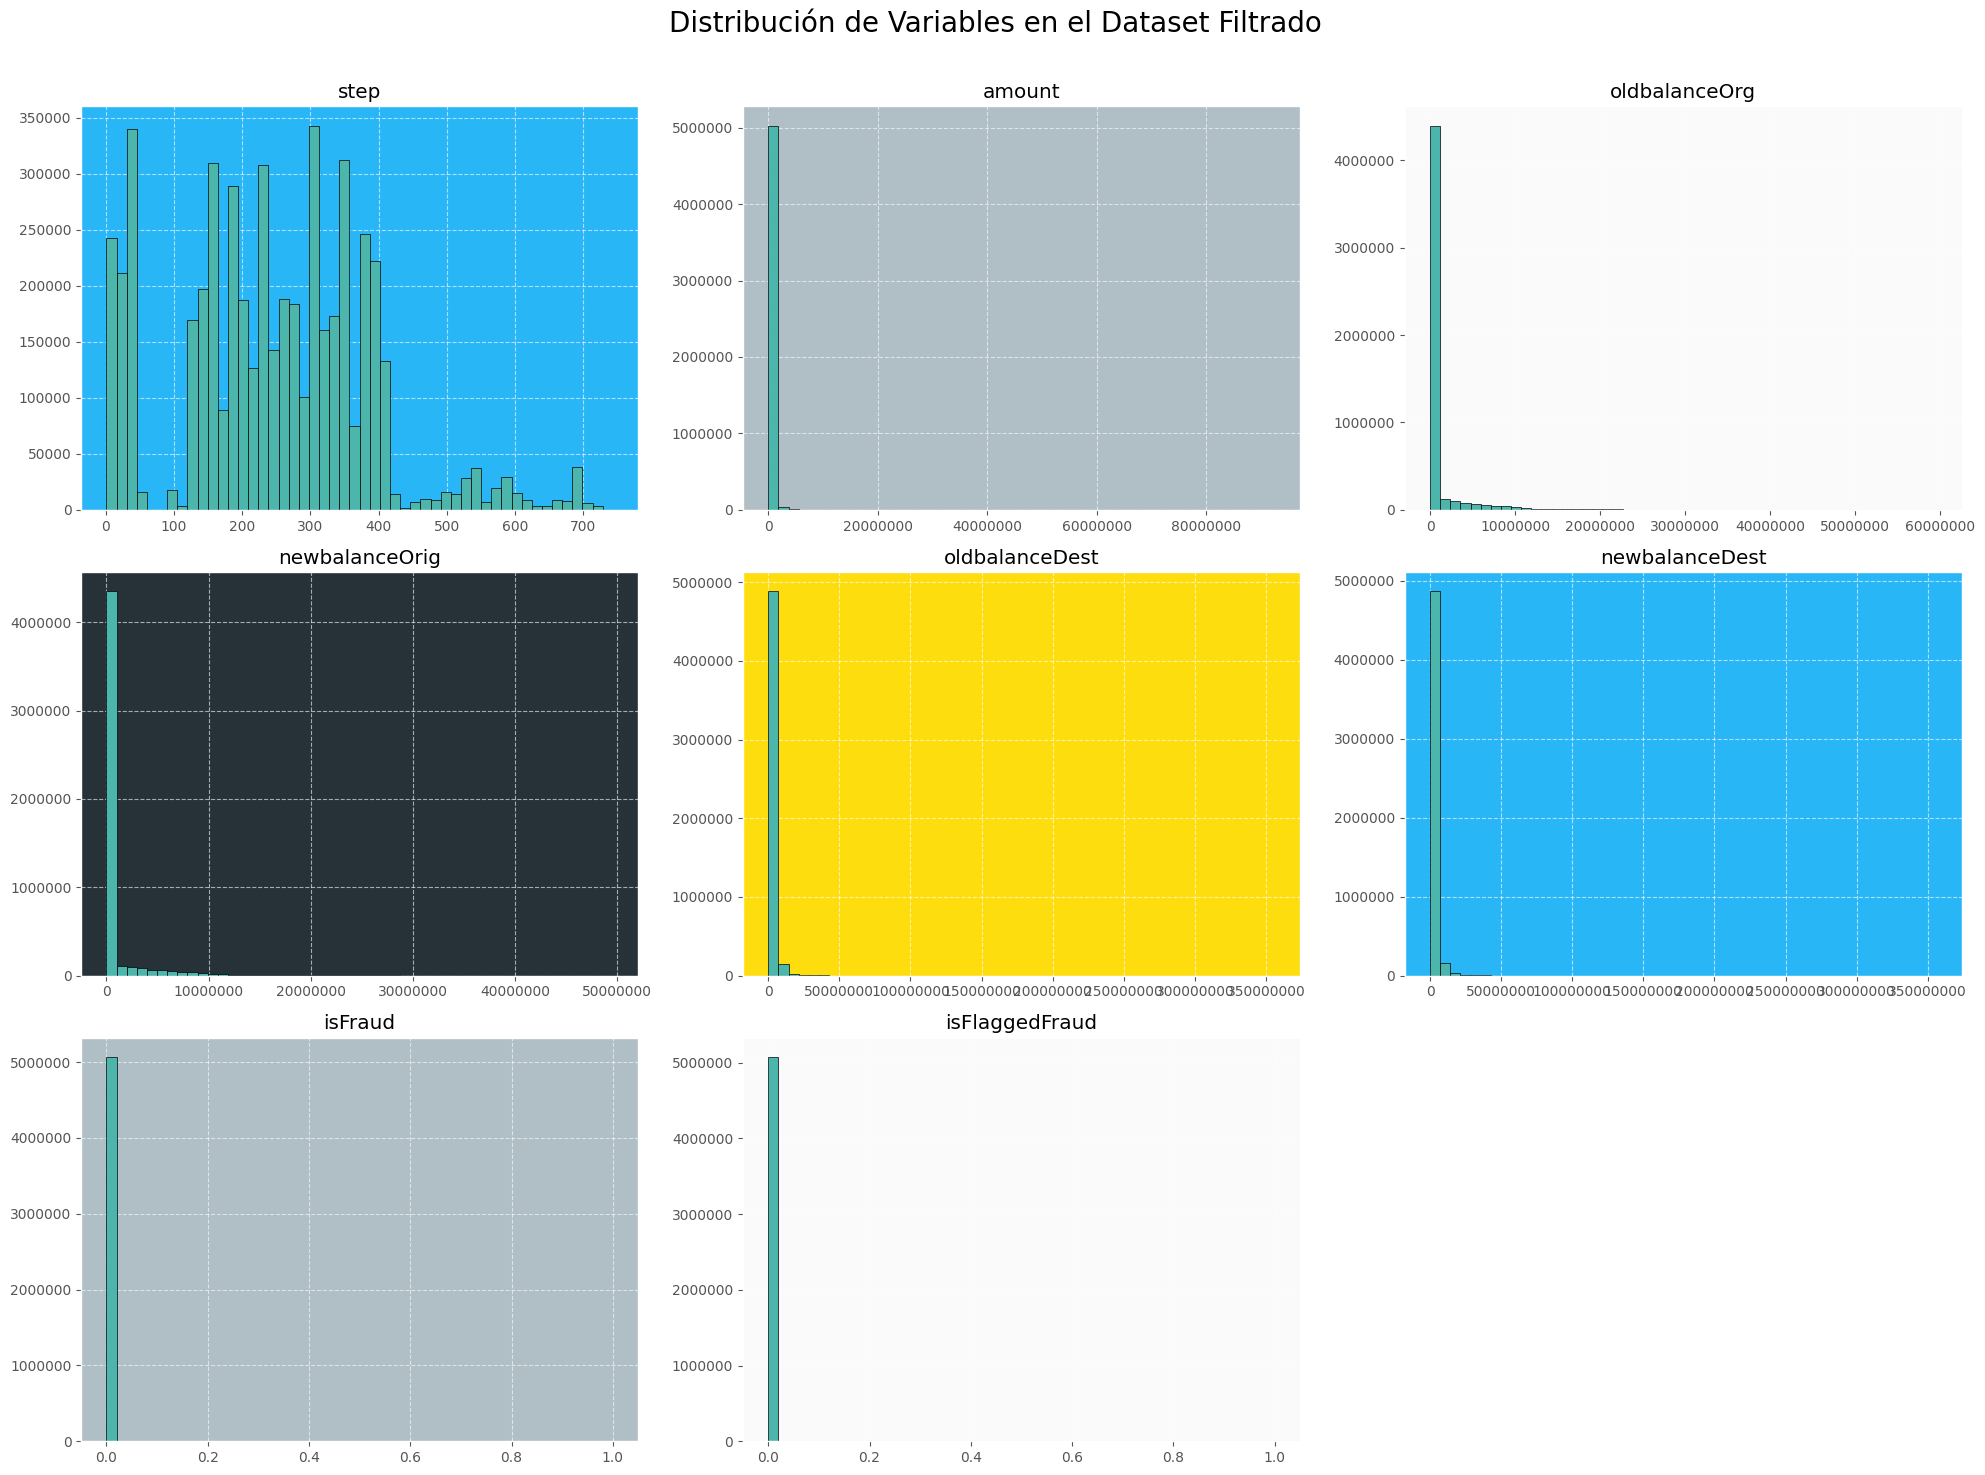

In [17]:
bin_color = "#4DB6AC"
background_palette = [color for color in fraudiq_palette if color != bin_color]

# 1. Histogramas
print("Generando histogramas para el dataset filtrado...")
df_numeric_filtered = df_filtered.select_dtypes(include=np.number)
axes = df_numeric_filtered.hist(bins=50, figsize=(20, 15), color=bin_color, edgecolor="black", grid=False)
axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    # Asignar un color de fondo de la paleta de forma cíclica
    ax.set_facecolor(background_palette[i % len(background_palette)])
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Distribución de Variables en el Dataset Filtrado", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Generando boxplots para el dataset filtrado...


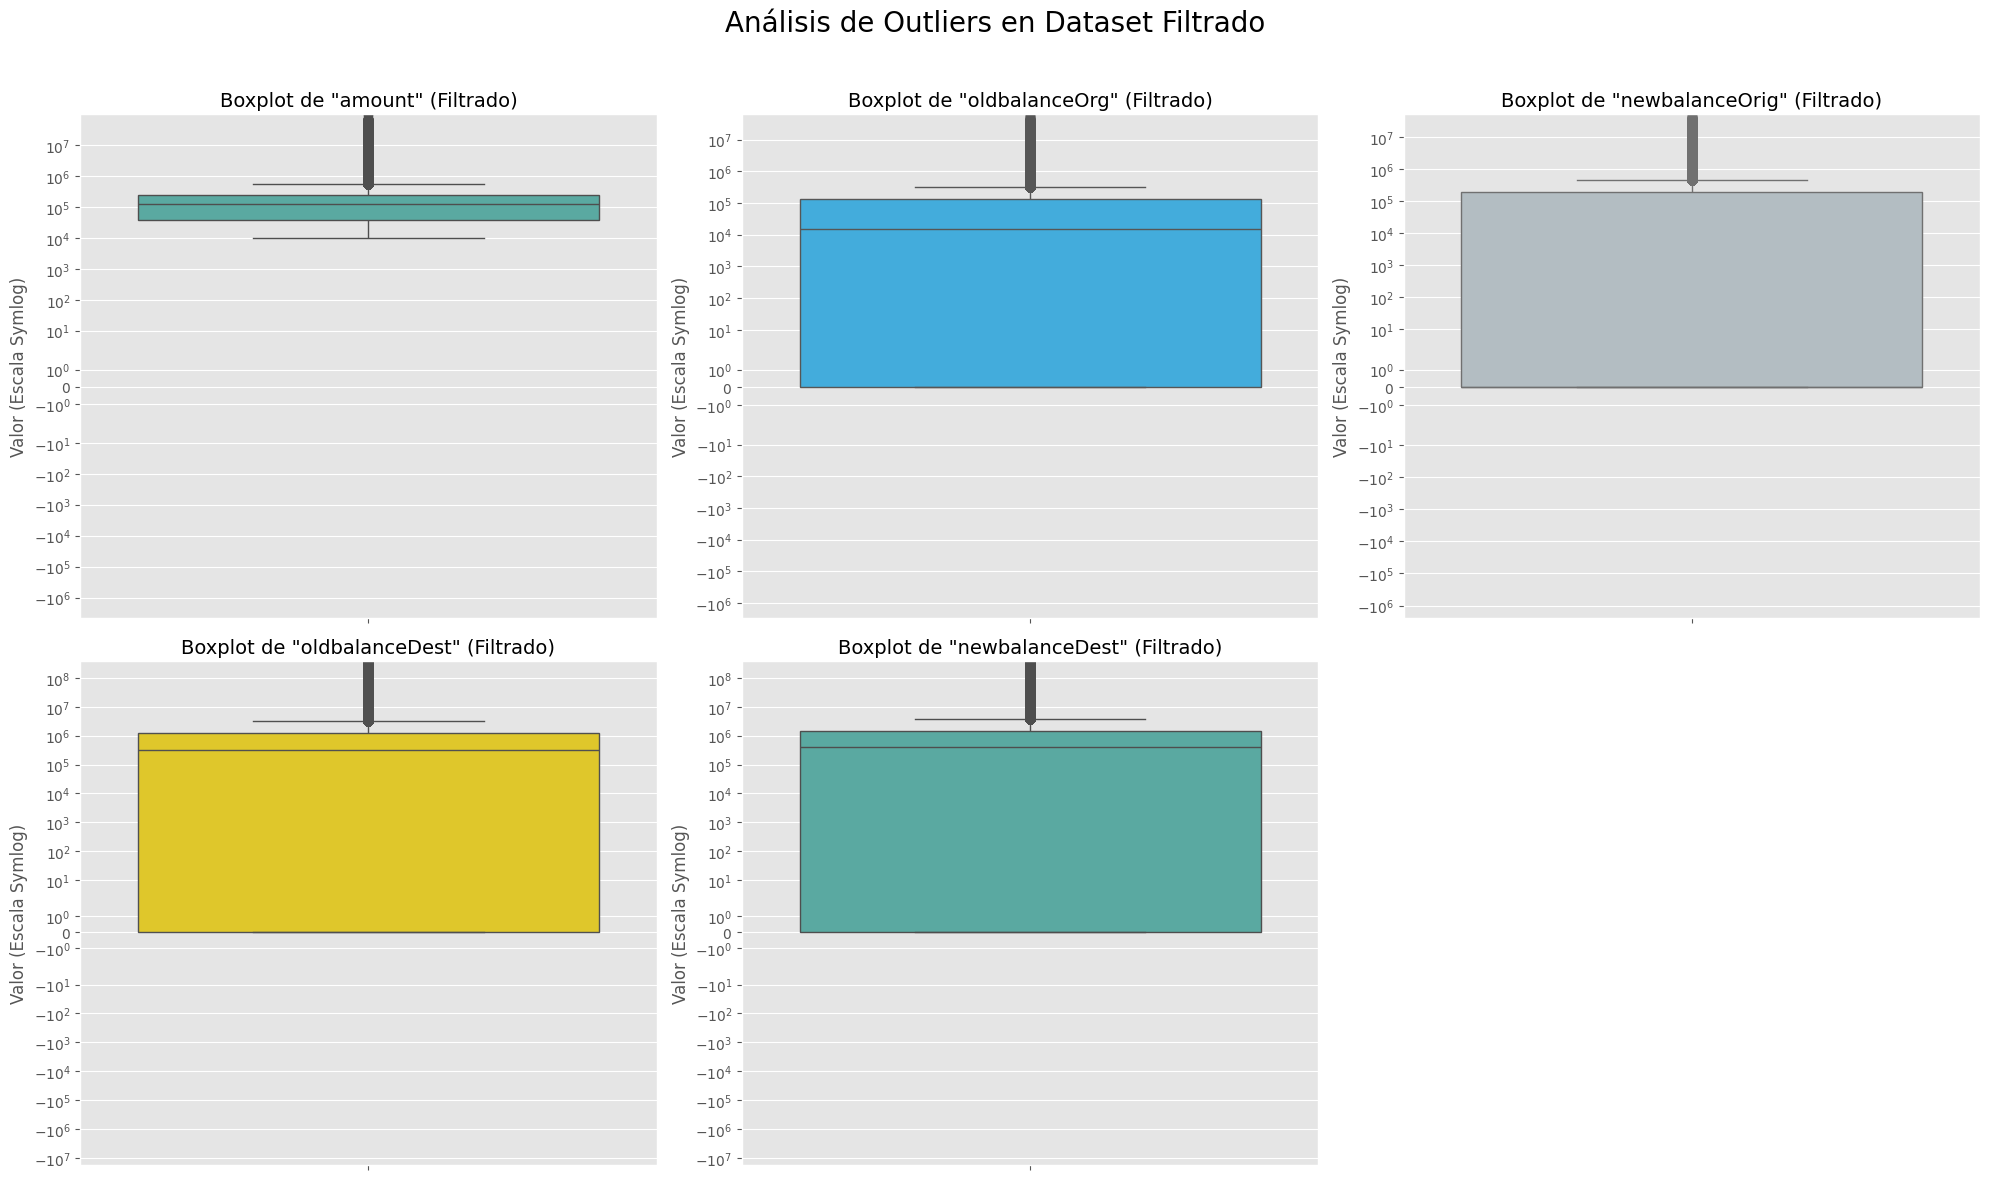

In [18]:
# 2. Boxplots
print("Generando boxplots para el dataset filtrado...")
variables_financieras = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
plt.figure(figsize=(20, 12))

for i, col in enumerate(variables_financieras):
    ax = plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_filtered[col], color=fraudiq_palette_2[i % len(fraudiq_palette_2)], ax=ax)
    ax.set_yscale('symlog')
    ax.set_title(f'Boxplot de "{col}" (Filtrado)', fontsize=14)
    ax.set_ylabel("Valor (Escala Symlog)")
    ax.set_xlabel("")

plt.suptitle("Análisis de Outliers en Dataset Filtrado", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Paso 10.1: Análisis de la Variable Objetivo (isFraud)

Finalmente, y muy importante, veamos cómo quedó el balance de la variable isFraud. Necesitamos saber cuántas transacciones fraudulentas y no fraudulentas tenemos en nuestro nuevo conjunto de datos.

In [19]:
print("Conteo de la variable 'isFraud' en el dataset filtrado:\n")
print(df_filtered['isFraud'].value_counts())

Conteo de la variable 'isFraud' en el dataset filtrado:

isFraud
0    5068594
1       7935
Name: count, dtype: int64


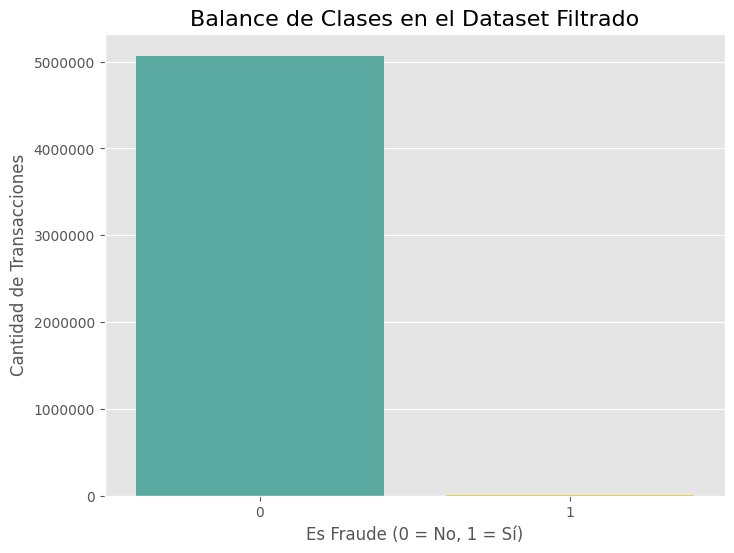

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(x='isFraud', data=df_filtered, hue='isFraud', palette=["#4DB6AC", "#FDDD0D"], legend=False)
plt.title('Balance de Clases en el Dataset Filtrado', fontsize=16)
plt.xlabel('Es Fraude (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Transacciones')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Paso 10.2: Conclusiones del Balance de Clases

El análisis de la variable objetivo isFraud en nuestro dataset filtrado revela un extremo desbalance de clases. Tenemos:

- Transacciones No Fraudulentas (Clase 0): 5,068,594

- Transacciones Fraudulentas (Clase 1): 7,935

Esto significa que las transacciones fraudulentas representan aproximadamente el 0.16% del conjunto de datos con el que trabajaremos.

#### Implicaciones para el Modelo

Este severo desbalance es un punto crítico que debemos abordar. Si entrenáramos un modelo de machine learning directamente con estos datos, este tendería a volverse "perezoso": podría alcanzar una precisión superior al 99% simplemente prediciendo siempre "No Fraude". Sin embargo, sería un modelo completamente inútil, ya que su capacidad para detectar la clase minoritaria (el fraude), que es nuestro verdadero objetivo, sería prácticamente nula.

Por lo tanto, antes de la etapa de entrenamiento, será obligatorio aplicar técnicas de manejo de datos desbalanceados, como el submuestreo (undersampling), el sobremuestreo (oversampling, por ejemplo, con SMOTE) o una combinación de ambos, para asegurar que el modelo aprenda a identificar correctamente ambos tipos de transacciones.

## Paso 11: Codificación de Variables Categóricas

Los algoritmos de machine learning operan con datos numéricos, por lo que no pueden procesar directamente columnas de texto como type (que contiene valores como 'CASH_OUT', 'TRANSFER', etc.). Por esta razón, es indispensable codificar estas variables, es decir, transformarlas en una representación numérica.

Estrategia de Codificación: One-Hot Encoding
Para la columna type, utilizaremos la técnica de One-Hot Encoding. Este método crea nuevas columnas binarias (con valores de 0 o 1) para cada categoría presente en la variable original. Por ejemplo, una transacción de tipo 'PAYMENT' tendrá un 1 en la nueva columna type_PAYMENT y un 0 en las demás.

Esta técnica es ideal porque:

Evita crear una relación de orden artificial entre las categorías (por ejemplo, no asume que 'TRANSFER' es "mayor" que 'PAYMENT').

Es fácilmente interpretable y se implementa de manera sencilla con la librería pandas.

In [21]:
print("Aplicando One-Hot Encoding a la columna 'type'...")

# Usamos pd.get_dummies para la codificación
# prefix='type' para que las nuevas columnas se llamen 'type_CASH_OUT', etc.
df_encoded = pd.get_dummies(df_filtered, columns=['type'], prefix='type', dtype=int)


# Mostramos las primeras filas para ver el resultado
# Ahora deberías ver las nuevas columnas al final del dataframe
print("\nVista del dataset con las variables categóricas codificadas:")
display(df_encoded.head())

# Verificamos las nuevas dimensiones
print("\nNuevas dimensiones del dataset:", df_encoded.shape)

Aplicando One-Hot Encoding a la columna 'type'...

Vista del dataset con las variables categóricas codificadas:


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
4,1,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,0,0,0,1,0
13,1,11633.76,C1716932897,10127.00,0.00,M801569151,0.00,0.00,0,0,0,0,0,1,0
15,1,229133.94,C905080434,15325.00,0.00,C476402209,5083.00,51513.44,0,0,0,1,0,0,0
19,1,215310.30,C1670993182,705.00,0.00,C1100439041,22425.00,0.00,0,0,0,0,0,0,1
24,1,311685.89,C1984094095,10835.00,0.00,C932583850,6267.00,2719172.89,0,0,0,0,0,0,1



Nuevas dimensiones del dataset: (5076529, 15)


## Paso 12: Selección Final de Características (Feature Selection)

No todas las columnas de nuestro dataset son útiles para predecir el fraude. Algunas, como los identificadores de cliente, no solo no aportan información generalizable, sino que pueden perjudicar al modelo. Si las incluimos, el modelo podría "memorizar" que la cuenta C12345 es fraudulenta, en lugar de aprender los patrones de comportamiento (montos, balances, tipo de transacción) que caracterizan al fraude en general.

Por lo tanto, eliminaremos las siguientes columnas:

- `nameOrig` y `nameDest`: Son identificadores únicos de clientes.

- `isFlaggedFraud`: Es una columna redundante generada por un sistema interno con reglas simples, y nuestro objetivo es crear un modelo de machine learning más sofisticado.

In [22]:
# Lista de columnas que vamos a eliminar
columns_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']

# Creamos un nuevo dataframe sin estas columnas
# axis=1 indica que estamos eliminando columnas, no filas
df_final_features = df_encoded.drop(columns=columns_to_drop, axis=1)

print("Columnas eliminadas. Vista previa del dataset final de características:")
display(df_final_features.head())

print("\nDimensiones finales del dataset:", df_final_features.shape)

Columnas eliminadas. Vista previa del dataset final de características:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,0,0,0,1,0
13,1,11633.76,10127.00,0.00,0.00,0.00,0,0,0,0,1,0
15,1,229133.94,15325.00,0.00,5083.00,51513.44,0,0,1,0,0,0
19,1,215310.30,705.00,0.00,22425.00,0.00,0,0,0,0,0,1
24,1,311685.89,10835.00,0.00,6267.00,2719172.89,0,0,0,0,0,1



Dimensiones finales del dataset: (5076529, 12)


### Ingeniería de Características Temporales

Aunque la columna step contiene información temporal valiosa, un simple contador de horas no es la forma más efectiva para que un modelo de machine learning capture patrones. Por lo tanto, realizaremos un paso de ingeniería de características para transformar esta columna en variables más significativas que representen los patrones cíclicos del tiempo.

Con esto, el modelo podrá identificar si ciertas horas del día o días de la semana son más propensos al fraude. Crearemos las siguientes dos características y luego eliminaremos la columna step original:

hour_of_day: Representará la hora del día en un formato de 24 horas (valores de 0 a 23).

day_of_week: Representará el día de la semana (valores de 0 a 6), permitiendo al modelo detectar tendencias semanales.

In [23]:
print("Creando características temporales a partir de la columna 'step'...")

# Crear 'hour_of_day' (0-23)
df_final_features['hour_of_day'] = df_final_features['step'] % 24

# Crear 'day_of_week' (0-6, asumiendo que el día 0 es el inicio de la semana)
df_final_features['day_of_week'] = (df_final_features['step'] // 24) % 7

# Ahora que hemos extraído la información valiosa, podemos eliminar la columna original 'step'
df_final_features = df_final_features.drop('step', axis=1)

print("Columnas 'hour_of_day' y 'day_of_week' creadas. La columna 'step' ha sido eliminada.")
print("Vista previa del dataset con las nuevas características:")
display(df_final_features.head())
print("\nDimensiones finales del dataset:", df_final_features.shape)

Creando características temporales a partir de la columna 'step'...
Columnas 'hour_of_day' y 'day_of_week' creadas. La columna 'step' ha sido eliminada.
Vista previa del dataset con las nuevas características:


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,hour_of_day,day_of_week
4,11668.14,41554.00,29885.86,0.00,0.00,0,0,0,0,1,0,1,0
13,11633.76,10127.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0
15,229133.94,15325.00,0.00,5083.00,51513.44,0,0,1,0,0,0,1,0
19,215310.30,705.00,0.00,22425.00,0.00,0,0,0,0,0,1,1,0
24,311685.89,10835.00,0.00,6267.00,2719172.89,0,0,0,0,0,1,1,0



Dimensiones finales del dataset: (5076529, 13)


## Paso 13: Submuestreo Estratégico y Estratificado para Balancear Clases

Como se concluyó en el análisis exploratorio (Paso 10), nuestro dataset presenta un **desbalance de clases extremo**, con más de 5 millones de transacciones legítimas (`isFraud = 0`) frente a menos de 8,000 fraudulentas (`isFraud = 1`). Para evitar que el modelo se vuelva ineficaz al ignorar la clase minoritaria, aplicaremos una técnica de submuestreo.

Sin embargo, un muestreo aleatorio simple no es suficiente, ya que podría distorsionar la distribución interna de las características. Por ello, emplearemos un **submuestreo aleatorio estratificado**.

La estrategia será la siguiente:
1.  **Conservar el 100%** de las muestras fraudulentas (`isFraud = 1`), que son nuestros datos más valiosos.
2.  **Seleccionar una muestra estratificada** de las transacciones no fraudulentas (`isFraud = 0`). La estratificación se hará en base a la columna `type`, asegurando que la proporción de 'CASH_OUT', 'PAYMENT', etc., en nuestra muestra sea idéntica a la del conjunto de datos original.
3.  **Unir ambos grupos** para formar un nuevo dataset, más pequeño, balanceado y, crucialmente, **representativo de la realidad** de los datos.

Con esto, garantizamos un entrenamiento más eficiente y un modelo que aprende de una versión fiel y en miniatura del comportamiento de los datos, reduciendo sesgos y mejorando su capacidad de generalización.

In [30]:
from sklearn.model_selection import train_test_split

# 1. Separar las transacciones fraudulentas y no fraudulentas
df_fraud = df_final_features[df_final_features['isFraud'] == 1].copy()
df_non_fraud = df_final_features[df_final_features['isFraud'] == 0].copy()

# Para poder estratificar, necesitamos una sola columna 'type'
# La recreamos temporalmente a partir de las columnas one-hot encoded
type_columns = [col for col in df_non_fraud.columns if 'type_' in col]
df_non_fraud['type'] = df_non_fraud[type_columns].idxmax(axis=1)

print("--- Distribución Original de Tipos en 'No Fraude' ---")
print(df_non_fraud['type'].value_counts(normalize=True).round(4))

# 2. Definir la nueva proporción
ratio = 10
num_fraud = len(df_fraud)
sample_size = int(num_fraud * ratio)

# 3. Tomar la MUESTRA ESTRATIFICADA
# Usamos train_test_split para obtener nuestra muestra. El resto se descarta.
df_non_fraud_sampled, _ = train_test_split(
    df_non_fraud,
    train_size=sample_size,
    random_state=42,
    stratify=df_non_fraud['type'] # ¡Aquí está la magia!
)

# Eliminamos la columna temporal 'type' que ya no necesitamos
df_non_fraud_sampled = df_non_fraud_sampled.drop('type', axis=1)

--- Distribución Original de Tipos en 'No Fraude' ---
type
type_CASH_OUT   0.43
type_CASH_IN    0.27
type_PAYMENT    0.20
type_TRANSFER   0.10
type_DEBIT      0.00
Name: proportion, dtype: float64


In [31]:
# --- VERIFICACIÓN (DESPUÉS) ---
# Recreamos 'type' en la muestra para verificar que la proporción se mantuvo
df_non_fraud_sampled['type'] = df_non_fraud_sampled[type_columns].idxmax(axis=1)
print("\n--- Distribución de Tipos en la Muestra Estratificada ---")
print(df_non_fraud_sampled['type'].value_counts(normalize=True).round(4))
df_non_fraud_sampled = df_non_fraud_sampled.drop('type', axis=1) # La volvemos a quitar

# 4. Concatenar y mezclar
df_balanced = pd.concat([df_fraud, df_non_fraud_sampled], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n--- Resultados Finales del Submuestreo Estratificado ---")
print(f"Nuevo dataset balanceado: {df_balanced.shape[0]:,} filas")
print(df_balanced['isFraud'].value_counts())


--- Distribución de Tipos en la Muestra Estratificada ---
type
type_CASH_OUT   0.43
type_CASH_IN    0.27
type_PAYMENT    0.20
type_TRANSFER   0.10
type_DEBIT      0.00
Name: proportion, dtype: float64

--- Resultados Finales del Submuestreo Estratificado ---
Nuevo dataset balanceado: 87,285 filas
isFraud
0    79350
1     7935
Name: count, dtype: int64


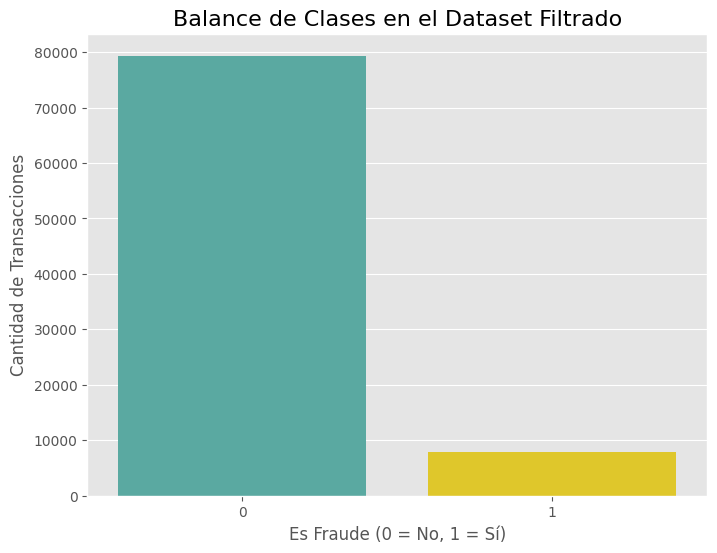

In [32]:
plt.figure(figsize=(8, 6))
sns.countplot(x='isFraud', data=df_balanced, hue='isFraud', palette=["#4DB6AC", "#FDDD0D"], legend=False)
plt.title('Balance de Clases en el Dataset Filtrado', fontsize=16)
plt.xlabel('Es Fraude (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Transacciones')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [33]:
# Dimensiones finales del dataset antes de exportar
df_balanced.shape

(87285, 13)

## Resumen del Proceso de Preparación de Datos

El dataset final, con dimensiones de 126960 filas y 13 columnas, es el resultado de un riguroso proceso de limpieza, ingeniería de características y preprocesamiento. El objetivo fue transformar el conjunto de datos crudo en una versión optimizada, balanceada y lista para el entrenamiento de modelos de machine learning.

Los pasos clave realizados fueron:

- Filtrado Estratégico: Se eliminaron más de 1.2 millones de transacciones con montos inferiores a $10,000. Esta decisión, justificada por los umbrales de la Ley de Secreto Bancario (BSA) de EE. UU., permitió reducir el ruido y enfocar el análisis en las operaciones más significativas.

- Ingeniería de Características: Se transformaron las características originales para aportar más valor al modelo. Esto incluyó la codificación One-Hot Encoding de la variable type y la conversión de la columna step (horas) en características cíclicas más potentes: hour_of_day y day_of_week.

- Selección de Características: Se descartaron columnas no informativas o redundantes como los identificadores de cliente (nameOrig, nameDest) y la bandera isFlaggedFraud.

- Balanceo de Clases (Submuestreo Estratificado): Se corrigió el severo desbalance entre transacciones fraudulentas y no fraudulentas. Para ello, se conservaron todos los casos de fraude y se tomó una muestra aleatoria estratificada de los casos no fraudulentos, asegurando así una representación proporcional de los tipos de transacción. Este fue el paso que redujo drásticamente el tamaño del dataset a su forma final.

## Paso 14: Exportación del Dataset Final para Modelado

Hemos llegado al final de la fase de limpieza y preparación. El resultado es un dataframe que contiene únicamente las características seleccionadas y transformadas, listas para ser utilizadas en la siguiente etapa del proyecto: el entrenamiento de los modelos.

Ahora exportaremos este dataframe final a un nuevo archivo en formato CSV. Este archivo será el punto de partida para nuestro próximo notebook, que se centrará exclusivamente en el modelado.

In [34]:
# Definimos el nombre del archivo de salida
output_filename = 'fraudiq_dataset_limpio.csv'

# Usamos la función to_csv de pandas para guardar el dataframe.
# Es muy importante usar index=False para evitar que se guarde el índice como una columna.
df_balanced.to_csv(output_filename, index=False)

print(f"¡Proceso de limpieza y preparación finalizado!")
print(f"El dataset limpio ha sido guardado exitosamente como: '{output_filename}'")

¡Proceso de limpieza y preparación finalizado!
El dataset limpio ha sido guardado exitosamente como: 'fraudiq_dataset_limpio.csv'


### Diccionario de Datos del Dataset Final

Se presenta el diccionario de datos final para el dataset `fraudiq_dataset_limpio.csv`. Este describe cada una de las características (features) que serán utilizadas para el entrenamiento de los modelos de detección de fraude.

### Variables Predictoras (X)

| Característica | Tipo de Dato | Descripción | Origen / Transformación |
| :--- | :--- | :--- | :--- |
| **amount** | Numérico (float) | Monto de la transacción. | Original |
| **oldbalanceOrg** | Numérico (float) | Saldo del emisor antes de la transacción. | Original |
| **newbalanceOrig** | Numérico (float) | Saldo del emisor después de la transacción. | Original |
| **oldbalanceDest** | Numérico (float) | Saldo del destinatario antes de la transacción. | Original |
| **newbalanceDest** | Numérico (float) | Saldo del destinatario después de la transacción. | Original |
| **type_CASH_IN** | Binario (int) | 1 si la transacción fue un depósito, 0 si no. | One-Hot Encoding |
| **type_CASH_OUT** | Binario (int) | 1 si la transacción fue un retiro, 0 si no. | One-Hot Encoding |
| **type_DEBIT** | Binario (int) | 1 si la transacción fue un débito, 0 si no. | One-Hot Encoding |
| **type_PAYMENT** | Binario (int) | 1 si la transacción fue un pago, 0 si no. | One-Hot Encoding |
| **type_TRANSFER** | Binario (int) | 1 si la transacción fue una transferencia, 0 si no. | One-Hot Encoding |
| **hour_of_day** | Numérico (int) | Hora del día (0-23) en que ocurrió la transacción. | Ingeniería de `step` |
| **day_of_week** | Numérico (int) | Día de la semana (0-6) en que ocurrió la transacción. | Ingeniería de `step` |

### Variable Objetivo (y)

| Característica | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| **isFraud** | Binario (int) | 1 si la transacción es fraudulenta, 0 si es legítima. |


In [35]:
df_balanced.shape


(87285, 13)

## FIN DEL DOCUMENTO

> REALIZADO POR DEYBBY ROSARIO 2024-0504 Y SARAH PEÑA 2024-0506


